# Rendering Meshes (Beginner-Friendly)
**with PyVista (VTK-powered)**  
**Last updated:** 2025-11-09

This tutorial shows how to **load meshes**, **render them nicely**, take **screenshots**, and make simple **MP4 animations**. We’ll use **PyVista** for convenience, which runs on top of VTK. No prior 3D experience required.

In [1]:
import numpy as np
from IPython.display import Image, display
import pyvista as pv
from pathlib import Path

print('PyVista version:', getattr(pv, '__version__', 'not found'))

PyVista version: 0.46.4


## 1. Create or load a mesh
We’ll start with **procedural shapes** (sphere, torus) so the notebook works anywhere. Replace these with your own files later (STL/PLY/OBJ/GLTF).

In [6]:
mesh = pv.read(Path('../example_data') / 'model.stl')
scene = sphere.merge(torus)
scene

PolyData (0x72202c1e04c0)
  N Cells:    27538
  N Points:   13771
  N Strips:   0
  X Bounds:   -4.998e-01, 2.850e+00
  Y Bounds:   -1.249e+00, 1.250e+00
  Z Bounds:   -5.000e-01, 5.000e-01
  N Arrays:   1

## 2. Basic rendering and screenshots
- **Smooth shading** improves appearance (requires normals).
- Control **background**, **lighting**, and **camera**.
- Save a **PNG screenshot** (off-screen rendering).

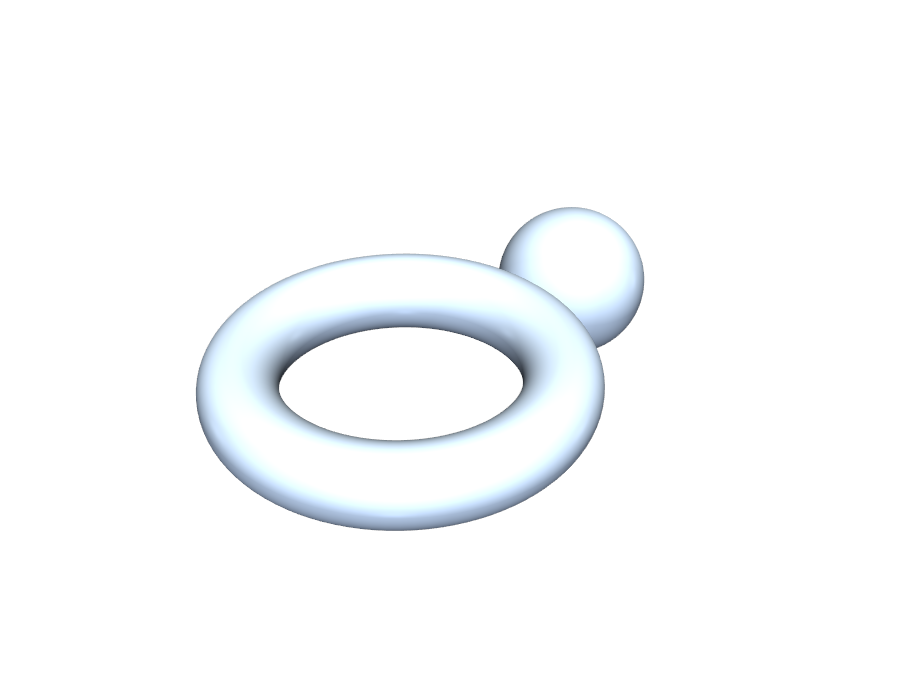

In [25]:
pl = pv.Plotter(off_screen=True, window_size=(900, 700))
# Add mesh with a nice material
pl.add_mesh(scene, smooth_shading=True, specular=0.3, metallic=0.0, roughness=0.4, color='lightsteelblue')
pl.set_background('white')

# Camera: position, focal_point, view_up
pl.camera_position = 'iso'  # isometric preset

# Optional: lights (adding a gentle headlight)
try:
    light = pv.Light(position=(5, 5, 5), light_type='scene light')
    light.intensity = 0.8
    pl.add_light(light)
except Exception:
    pass

png_path = 'render_basic.png'
pl.show(screenshot=png_path, jupyter_backend="static")


## 3. Materials, colors, and scalar coloring
You can color by **single color**, per-vertex **scalars** (with colormaps), and tweak materials. Below we add a synthetic scalar to the sphere and render a two-mesh scene.

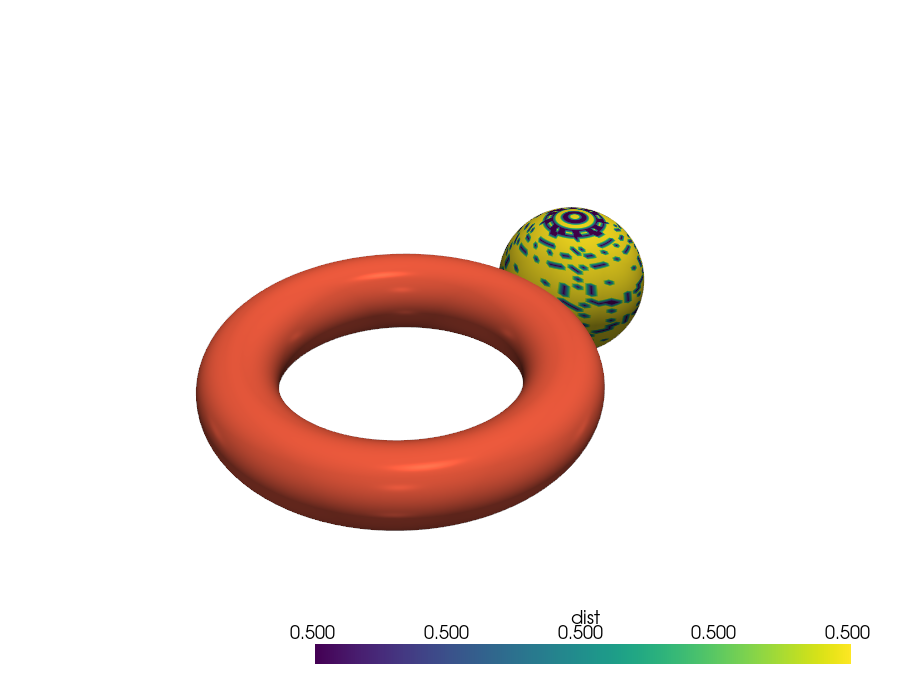

In [26]:
# Make scalars on the sphere: distance-from-center
sphere2 = pv.Sphere(radius=0.5, theta_resolution=64, phi_resolution=64)
scalars = np.linalg.norm(sphere2.points, axis=1)
sphere2.point_data['dist'] = scalars

torus2 = pv.ParametricTorus(ringradius=1.0, crosssectionradius=0.25).triangulate()
torus2.translate([1.6, 0, 0], inplace=True)

pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background('white')
pl.add_mesh(sphere2, scalars='dist', cmap='viridis', smooth_shading=True)
pl.add_mesh(torus2, color='tomato', smooth_shading=True, specular=0.4)
pl.camera_position = 'iso'
png_path = 'render_coloring.png'
pl.show(screenshot=png_path, jupyter_backend="static")


## 4. Multi-view (side-by-side) renders
Show several variants at once: different materials, colors, or decimation settings, rendered into a single PNG.

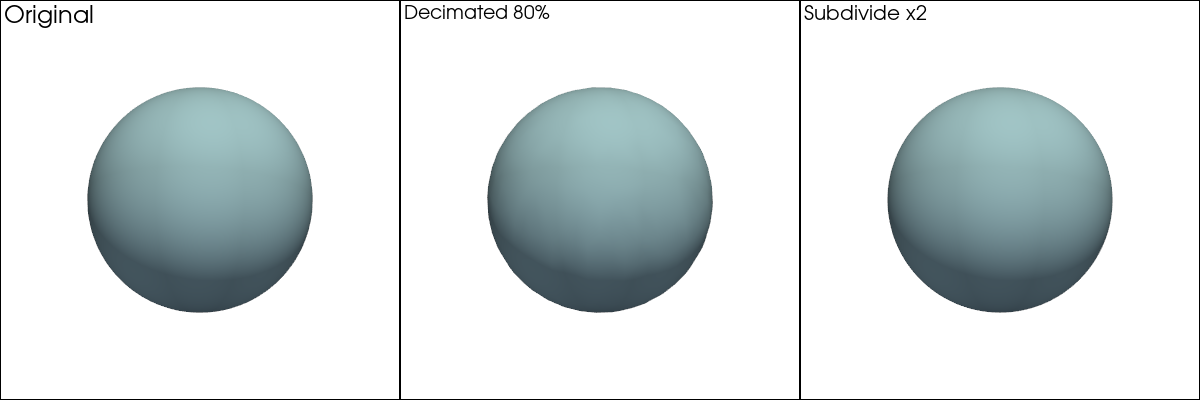

In [27]:
base = pv.Sphere(radius=0.6, theta_resolution=64, phi_resolution=64)
coarse = base.decimate(0.8)
ultra = base.subdivide(2, subfilter='loop')

plotter = pv.Plotter(shape=(1,3), off_screen=True, window_size=(1200, 400))
for i, (mesh, title) in enumerate([(base, 'Original'), (coarse, 'Decimated 80%'), (ultra, 'Subdivide x2')]):
    plotter.subplot(0, i)
    plotter.add_mesh(mesh, smooth_shading=True, color='lightblue')
    plotter.add_text(title, font_size=10)
    plotter.set_background('white')
    plotter.camera_position = 'iso'
plotter.link_views()
png = 'render_multiview.png'
plotter.show(screenshot=png, jupyter_backend="static")


## 5. Turntable animation (camera orbit) → MP4
A **turntable** animation rotates the camera around your object. We’ll write an **MP4** using PyVista’s movie API. If MP4 writing fails, check that `imageio-ffmpeg` is installed.

In [17]:
mesh = pv.Sphere(radius=0.9, theta_resolution=128, phi_resolution=128)

pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background('white')

pl.add_mesh(sphere2, scalars='dist', cmap='viridis', smooth_shading=True)
pl.add_mesh(torus2, color='tomato', smooth_shading=True, specular=0.4)
pl.camera_position = 'iso'

mp4_path = 'turntable.mp4'
try:
    pl.open_movie(mp4_path, framerate=30)
    pl.show(auto_close=False)  # initialize without closing
    n_frames = 180
    for i in range(n_frames):
        pl.camera.azimuth += 2.0  # 180 * 2° = full 360°
        pl.write_frame()
    pl.close()  # finalize movie
    print('Saved MP4:', mp4_path)
except Exception as e:
    print('Movie failed:', e)

from IPython.display import Video
Video(mp4_path, width=800)

Widget(value='<iframe src="http://localhost:43649/index.html?ui=P_0x722013643aa0_5&reconnect=auto" class="pyvi…

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (900, 700) to (912, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved MP4: turntable.mp4


## 6. Keyframe-style animation (rotate mesh + camera) → MP4
Here we rotate the **mesh** and the **camera** together and record a short MP4.

In [24]:
mesh = pv.ParametricTorus(ringradius=1.0, crosssectionradius=0.25).triangulate()

pl = pv.Plotter(off_screen=True, window_size=(900, 700))
actor = pl.add_mesh(mesh, color='salmon', smooth_shading=True)
pl.set_background('white')
pl.camera_position = 'iso'

mp4_path = 'keyframes.mp4'
try:
    pl.open_movie(mp4_path, framerate=30)
    pl.show(auto_close=False)
    for i in range(130):  # ~4 seconds
        mesh.rotate_z(3.0, inplace=True)
        pl.camera.elevation += 0.5
        pl.camera.azimuth += 1.0
        pl.update()
        pl.write_frame()
    pl.close()
    print('Saved MP4:', mp4_path)
except Exception as e:
    print('Movie failed:', e)

Video(mp4_path, width=800)

Widget(value='<iframe src="http://localhost:43649/index.html?ui=P_0x72202470bb90_9&reconnect=auto" class="pyvi…

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (900, 700) to (912, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved MP4: keyframes.mp4


## 8. Reading mesh files
Use `pv.read(path)` for STL, PLY, OBJ, GLTF, and many others. Example:

```python
import pyvista as pv
mesh = pv.read('model.stl')
mesh = pv.read('model.ply')
mesh = pv.read('model.obj')
mesh = pv.read('model.gltf')  # if supported
```
**Tip:** Some formats don’t store units. Keep track of your scale.

## 9. Tips & troubleshooting
- **Jagged edges?** Ensure your mesh has **normals** (`smooth_shading=True` computes them automatically).
- **Too shiny/dull?** Tweak `specular`, `metallic`, and `roughness`.
- **Slow rendering?** Try **decimation** first: `mesh.decimate(0.5)`.
- **Movie fails?** Check `imageio-ffmpeg` is installed, or write PNG frames and stitch with FFmpeg.